<h2><font color="orange">Atividade Avaliativa (AP2)</font></h2>

# 06 Déficit Habitacional

Rio de Janeiro (RJ) · EPSG:31983  
Habitação · Vulnerabilidade Social

Feito por: Gabriela da Costa, Isabela Athayde e Thiago Farias

# (01_ETL.IPYNB)
Download · limpeza · reprojeção (EPSG local) · join espacial · exportação GeoJSON
ETL (01_ETL.IPYNB)<br>
**• Download dos resultados do Censo 2022 por
setor censitário<br>
• Reprojeção para EPSG:31983; join com
municípios RJ<br>
• Cálculo do déficit habitacional por tipo (ônus
excessivo/coabitação/etc.)<br>
• Exportar deficit-habitacional-rj.geojson e
municipios-rj.geojson**

In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px
import geopandas as gpd
import pandas as pd
import numpy as np
import os
import io
import requests
from zipfile import ZipFile

# configuração geral
diretorio="dados"

if not os.path.exists(diretorio):
  os.makedirs(diretorio)

### Imports Setor Censitário, Municipios RJ e Renda RJ

In [ ]:
# download censo 2022 por setor censitário
url_setores_2022="https://ftp.ibge.gov.br/Censos/Censo_Demografico_2022/Agregados_por_Setores_Censitarios/Agregados_por_Setor_csv/Agregados_por_setores_basico_BR_20260520.zip"
caminho_setores_2022=os.path.join(diretorio, "Agregados_por_setores_basico_BR.csv")

if not os.path.exists(caminho_setores_2022):
  response=requests.get(url_setores_2022)
  with ZipFile(io.BytesIO(response.content)) as zObject:
    zObject.extractall(path=diretorio)

df_setores=pd.read_csv(caminho_setores_2022, encoding='latin1',sep=';',low_memory=False, decimal=',').query('CD_UF==33')

In [ ]:
# download e exportação geodata rio
url_33_muni="https://raw.githubusercontent.com/tbrugz/geodata-br/refs/heads/master/geojson/geojs-33-mun.json"
arq_33_muni="geojs-33-mun.json"
caminho_33_muni=os.path.join(diretorio, arq_33_muni)

if not os.path.exists(caminho_33_muni):
  gdf_33_muni=gpd.read_file(url_33_muni)
  gdf_33_muni.to_file(caminho_33_muni, driver='GeoJSON')
else:
  gdf_33_muni=gpd.read_file(caminho_33_muni)

In [ ]:
# download da renda domiciliar média
url_renda = "https://raw.githubusercontent.com/minesweepr/4UBD-Deficit-Habitacional/main/renda_rj.csv";
caminho_renda = os.path.join(diretorio, "renda_rj.csv");

if not os.path.exists(caminho_renda):
    df_renda = pd.read_csv( url_renda, sep=";", decimal=",", encoding="utf-8")
else:
    df_renda = pd.read_csv(caminho_renda,sep=";", decimal=",", encoding="utf-8");


# tratamento dos dados dessa tabela
df_renda = df_renda[
    df_renda['Município'].str.contains(r'\(RJ\)', na=False)
]
df_renda['Município'] = df_renda['Município'].str.replace(r'\s*\(RJ\)\s*', '', regex=True)

df_renda.rename(columns={'Total': 'renda'}, inplace=True)

df_renda['renda'] = (
    df_renda['renda']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df_renda['renda'] = pd.to_numeric(
    df_renda['renda'],
    errors='coerce'
)

df_renda.drop(columns="Grupo de idade", inplace=True)
display(df_renda.head(2))

,Município,renda
0,Angra dos Reis,1463.14
1,Aperibé,1360.14


### Outras importações

In [ ]:
# download da geometria de setores
url_setorGeo="https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_de_setores_censitarios__divisoes_intramunicipais/censo_2022/setores/gpkg/UF/RJ/RJ_setores_CD2022.gpkg"
caminho_url_setorGeo=os.path.join(diretorio, "RJ_setores_CD2022.gpkg")

if not os.path.exists(caminho_url_setorGeo):
    print("Baixando arquivo...")

    response = requests.get(url_setorGeo, stream=True)
    response.raise_for_status()

    with open(caminho_url_setorGeo, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)

gdfrj_setores = gpd.read_file(caminho_url_setorGeo)

Baixando arquivo...


In [ ]:
url_condicao = "https://raw.githubusercontent.com/minesweepr/4UBD-Deficit-Habitacional/refs/heads/main/condicao_ocupacao.csv";
caminho_condicao = os.path.join(diretorio, "condicao_ocupacao.csv");

if not os.path.exists(caminho_condicao):
    df_cond_domi = pd.read_csv(url_condicao, sep=";", decimal=",", encoding="utf-8")
else:
    df_cond_domi = pd.read_csv(caminho_condicao,sep=";", decimal=",", encoding="utf-8");

## tratamento

df_cond_domi.rename(columns={
    'Próprio de algum morador': 'Proprio',
    'Cedido ou emprestado': 'Cedido',
    'Outra condição': 'Outra_Condicao'
}, inplace=True)

df_cond_domi = df_cond_domi[
    df_cond_domi['Município'].str.contains(r'\(RJ\)', na=False)
]

df_cond_domi['Município'] = (
    df_cond_domi['Município']
    .str.replace(r'\s*\(RJ\)\s*', '', regex=True)
    .str.strip()
)

df_cond_domi['Outra_Condicao'] = (
    df_cond_domi['Outra_Condicao']
    .replace('-', np.nan)
    .astype(float)
)

### Reprojeção para EPSG:31983; join com municípios RJ

In [ ]:
# reprojeção para EPSG:31983
gdf_33_muni=gdf_33_muni.to_crs("EPSG:31983")

# agrupa e renomeia
df_valores=df_setores.groupby('CD_MUN').agg(
    populacao=('v0001', 'sum'),
    domicilios=('v0002', 'sum'),
    domicilios_ocupados=('v0003', 'sum'),
    domicilios_vagos=('v0004', 'sum'),
    media_moradores=('v0005', 'mean'),
    percentual_domicilios_particulares_ocupados_imputados=('v0006', 'sum'),
    domicilios_particulares_ocupados=('v0007', 'sum')
)

gdf_muni_rj=gdf_33_muni.merge(df_valores, left_on='id', right_index=True, how='left')

gdf_muni_rj.to_file(os.path.join(diretorio, "municipios-rj.geojson"), driver='GeoJSON')
display(gdf_muni_rj.head(2))

,id,name,description,geometry,populacao,domicilios,domicilios_ocupados,domicilios_vagos,media_moradores,percentual_domicilios_particulares_ocupados_imputados,domicilios_particulares_ocupados
0,3300100,Angra dos Reis,Angra dos Reis,"POLYGON ((582381.059 7445370.575, 582492.587 7...",167434,93974,93756,218,2.39873,9.6858,62147
1,3300159,Aperibé,Aperibé,"POLYGON ((798686.414 7608235.357, 798603.663 7...",11034,5358,5355,3,2.59375,1.0531,4345


### Cálculo do déficit habitacional por tipo

In [ ]:
# excesso de moradores
df_valores['excesso_moradores'] = (
    (
        df_valores['media_moradores'] - 2
    ).clip(lower=0)
)

# déficit absoluto
df_valores['deficit_absoluto'] = (
    df_valores['excesso_moradores']
    *
    df_valores['domicilios']
)

# déficit relativo
df_valores['deficit_relativo'] = (
    df_valores['deficit_absoluto']
    /
    df_valores['domicilios']
) * 100

display(
    df_valores[
        [
            'media_moradores',
            'deficit_absoluto',
            'deficit_relativo'
        ]
    ].describe()
)

,media_moradores,deficit_absoluto,deficit_relativo
count,92.000000,9.200000e+01,92.000000
mean,2.575678,4.408857e+04,57.567806
std,0.106246,1.486363e+05,10.624600
min,2.309459,1.464565e+03,30.945946
25%,2.510688,5.478405e+03,51.068845
50%,2.579518,1.137458e+04,57.951840
75%,2.638005,3.652037e+04,63.800505
max,2.893939,1.388256e+06,89.393939


In [ ]:
# agrupamento dos municípios
df_setores_agrupados = df_setores.groupby('CD_MUN').agg({
    'AREA_KM2': 'sum',
    'v0001': 'sum',
    'v0002': 'sum',
    'v0003': 'sum',
    'v0004': 'sum',
    'v0005': 'mean'
}).reset_index()

# renomear colunas
df_setores_agrupados = df_setores_agrupados.rename(columns={
    'v0001': 'populacao',
    'v0002': 'domicilios',
    'v0003': 'domicilios_ocupados',
    'v0004': 'domicilios_vagos',
    'v0005': 'media_moradores'
})

# cálculo do excesso
df_setores_agrupados['excesso_moradores'] = (
    (
        df_setores_agrupados['media_moradores'] - 2
    ).clip(lower=0)
)

# déficit absoluto
df_setores_agrupados['deficit_absoluto'] = (
    df_setores_agrupados['excesso_moradores']
    *
    df_setores_agrupados['domicilios']
)

# déficit relativo
df_setores_agrupados['deficit_relativo'] = (
    df_setores_agrupados['deficit_absoluto']
    /
    df_setores_agrupados['domicilios']
) * 100

# selecionar colunas
colunas_filtradas = [
    'CD_MUN',
    'excesso_moradores',
    'deficit_absoluto',
    'deficit_relativo'
]

df_valores = df_setores_agrupados[
    colunas_filtradas
]

# garantir mesmo tipo
gdf_muni_rj['id'] = (
    gdf_muni_rj['id'].astype(str)
)

df_valores.loc[:, 'CD_MUN'] = (
    df_valores['CD_MUN'].astype(str)
)

# merge
gdf_deficit = gdf_muni_rj.merge(
    df_valores,
    left_on='id',
    right_on='CD_MUN',
    how='left'
)

# exportação
caminho_deficit = os.path.join(
    diretorio,
    "deficit-habitacional-rj.geojson"
)

gdf_deficit.to_file(
    caminho_deficit,
    driver='GeoJSON'
)

# conferir
print(
    gdf_deficit['deficit_relativo'].min()
)

print(
    gdf_deficit['deficit_relativo'].max()
)

display(gdf_deficit.head(2))

30.945945945945972
89.3939393939394


,id,name,description,geometry,populacao,domicilios,domicilios_ocupados,domicilios_vagos,media_moradores,percentual_domicilios_particulares_ocupados_imputados,domicilios_particulares_ocupados,CD_MUN,excesso_moradores,deficit_absoluto,deficit_relativo
0,3300100,Angra dos Reis,Angra dos Reis,"POLYGON ((582381.059 7445370.575, 582492.587 7...",167434,93974,93756,218,2.39873,9.6858,62147,3300100,0.39873,37470.213793,39.872958
1,3300159,Aperibé,Aperibé,"POLYGON ((798686.414 7608235.357, 798603.663 7...",11034,5358,5355,3,2.59375,1.0531,4345,3300159,0.59375,3181.312500,59.375000


In [ ]:
# por inadequação
# juntando setor com renda, inadequação e municipio
df_inadequacao = df_setores.copy()

df_inadequacao['renda'] = (
    df_inadequacao['NM_MUN']
    .map(
        df_renda
        .set_index('Município')['renda']
    )
)

df_inadequacao['geometry'] = (
    df_inadequacao['NM_MUN']
    .map(
        gdf_muni_rj
        .set_index('name')['geometry']
    )
)

# descomentar pros index altos serem zerados, apagar se não quiser
#df_inadequacao=df_inadequacao.reset_index()

display(df_inadequacao[['NM_MUN','renda','geometry']].head(2))

,NM_MUN,renda,geometry
223221,Angra dos Reis,1463.14,"POLYGON ((582381.059 7445370.575, 582492.587 7..."
223222,Angra dos Reis,1463.14,"POLYGON ((582381.059 7445370.575, 582492.587 7..."


In [ ]:
df_inadequacao = df_inadequacao.rename(columns={
    'v0001': 'populacao',
    'v0002': 'domicilios',
    'v0003': 'domicilios_particulares',
    'v0004': 'domicilios_coletivos',
    'v0005': 'media_moradores',
    'v0006': 'percentual_domicilios',
    'v0007': 'domicilios_ocupados'
})

#coabitação
df_inadequacao['coabitacao'] = (
    (df_inadequacao['media_moradores'] - df_inadequacao['media_moradores'].min())
    /
    (df_inadequacao['media_moradores'].max() - df_inadequacao['media_moradores'].min())
)

# onus
renda_norm = (
    (df_inadequacao['renda'] - df_inadequacao['renda'].min())
    /
    (df_inadequacao['renda'].max() - df_inadequacao['renda'].min())
)

moradores_norm = (
    (df_inadequacao['media_moradores'] - df_inadequacao['media_moradores'].min())
    /
    (df_inadequacao['media_moradores'].max() - df_inadequacao['media_moradores'].min())
)

df_inadequacao['onus_excessivo'] = (
    (1 - renda_norm) * 0.7
    + moradores_norm * 0.3
)

# precariedade
mapa_tipo = {
    0: 'Não especial',
    1: 'Favela e Comunidade Urbana',
    2: 'Quartel e base militar',
    3: 'Alojamento / acampamento',
    4: 'Setor com baixo patamar domiciliar',
    5: 'Agrupamento indígena',
    6: 'Unidade prisional',
    7: 'Convento / hospital / ILPI / IACA',
    8: 'Agrovila do PA',
    9: 'Agrupamento quilombola'
}

df_inadequacao['CD_TIPO'] = pd.to_numeric(df_inadequacao['CD_TIPO'], errors='coerce')

df_inadequacao['NM_TIPO'] = df_inadequacao['CD_TIPO'].map(mapa_tipo)

setores_precarios = [
    'Favela e Comunidade Urbana',
    'Setor com baixo patamar domiciliar'
]

df_inadequacao['precariedade'] = (
    df_inadequacao['NM_TIPO'].isin(setores_precarios).astype(int)
)

df_inadequacao = df_inadequacao.drop(
    columns=['renda_norm', 'moradores_norm'],
    errors='ignore'
)

In [ ]:
## caso precise de mais colunas pode adicionar na linha abaixo.
df_inadequacao = df_inadequacao[['CD_MUN','NM_MUN','NM_REGIAO','SITUACAO','NM_TIPO','coabitacao','onus_excessivo','precariedade','domicilios','renda','populacao','geometry']]

df_inadequacao.head(2)

,CD_MUN,NM_MUN,NM_REGIAO,SITUACAO,NM_TIPO,coabitacao,onus_excessivo,precariedade,domicilios,renda,populacao,geometry
223221,3300100,Angra dos Reis,Sudeste,Urbana,Não especial,0.255556,0.606920,0,54,1463.14,66,"POLYGON ((582381.059 7445370.575, 582492.587 7..."
223222,3300100,Angra dos Reis,Sudeste,Urbana,Não especial,0.233333,0.600253,0,81,1463.14,79,"POLYGON ((582381.059 7445370.575, 582492.587 7..."


# (02_ANALISE.IPYNB)

EDA com 3 perguntas quantitativas · análise de correlação socioeconômica
ANÁLISE (02_ANALISE.IPYNB)<br>
**• Déficit habitacional absoluto e relativo por
município<br>
• Distribuição por tipo de inadequação (ônus,
precariedade, coabitação)<br>
• Ranking dos 20 municípios com maior déficit
relativo<br>
• Correlação: renda domiciliar x condição domiciliar**

### Déficit habitacional absoluto e relativo por município

In [ ]:
analise_deficit = gdf_deficit[
    [
        'name',
        'populacao',
        'deficit_absoluto',
        'deficit_relativo'
    ]
].sort_values(
    by='deficit_relativo',
    ascending=False
)

display(
    analise_deficit.head(20)
)

,name,populacao,deficit_absoluto,deficit_relativo
89,Varre-Sai,10207,4033.454545,89.393939
15,Comendador Levy Gasparian,8741,3130.084211,82.631579
34,Japeri,96289,30983.973333,79.380952
44,Miracema,26881,8921.194030,76.119403
45,Natividade,15074,5500.083019,73.207547
61,Quissamã,22393,8122.139326,73.146067
58,Porto Real,20373,6259.135088,71.754386
65,Rio das Flores,8954,2805.536842,70.526316
55,Pinheiral,24298,7447.403448,68.620690
51,Paraíba do Sul,42063,12978.859615,67.884615


### Distribuição por tipo de inadequação (ônus,precariedade, coabitação)

In [ ]:
df_distribuicao=df_inadequacao.groupby('NM_MUN')[['onus_excessivo','precariedade','coabitacao']].sum().reset_index()

# cálculos
df_distribuicao['total_inadequacao']=(df_distribuicao['onus_excessivo']+df_distribuicao['precariedade']+df_distribuicao['coabitacao'])
df_distribuicao['porcentagem_onus_excessivo']=((df_distribuicao['onus_excessivo']/df_distribuicao['total_inadequacao'])*100)
df_distribuicao['porcentagem_precariedade']=((df_distribuicao['precariedade']/df_distribuicao['total_inadequacao'])*100)
df_distribuicao['porcentagem_coabitacao']=((df_distribuicao['coabitacao']/df_distribuicao['total_inadequacao'])*100)

formatacao={'total_inadequacao':'{:.1f}', 'porcentagem_onus_excessivo':'{:.2f}%', 'porcentagem_precariedade':'{:.2f}%', 'porcentagem_coabitacao':'{:.2f}%'}

df_distribuicao=df_distribuicao[['NM_MUN',
                                 'total_inadequacao',
                                 'porcentagem_onus_excessivo',
                                 'porcentagem_precariedade',
                                 'porcentagem_coabitacao']].sort_values(by='total_inadequacao', ascending=False)
display(df_distribuicao.head(5).style.format(formatacao))

,NM_MUN,total_inadequacao,porcentagem_onus_excessivo,porcentagem_precariedade,porcentagem_coabitacao
67,Rio de Janeiro,11737.8,40.96%,26.74%,32.29%
77,São Gonçalo,2451.2,66.52%,6.61%,26.87%
24,Duque de Caxias,2026.8,64.36%,8.78%,26.85%
49,Nova Iguaçu,1740.6,66.80%,5.23%,27.97%
14,Campos dos Goytacazes,1400.6,63.23%,7.85%,28.92%


### Ranking dos 20 municípios com maior déficit relativo

In [ ]:
top20 = (
    gdf_deficit[
        ['name', 'deficit_relativo']
    ]
    .sort_values(
        by='deficit_relativo',
        ascending=False
    )
    .head(20)
)

display(top20)

,name,deficit_relativo
89,Varre-Sai,89.393939
15,Comendador Levy Gasparian,82.631579
34,Japeri,79.380952
44,Miracema,76.119403
45,Natividade,73.207547
61,Quissamã,73.146067
58,Porto Real,71.754386
65,Rio das Flores,70.526316
55,Pinheiral,68.620690
51,Paraíba do Sul,67.884615


### Correlação: renda x condição


In [ ]:
df_renda_dom = pd.merge(
    df_cond_domi,
    df_renda,
    on='Município',
    how='inner'
)

df_renda_dom = df_renda_dom[
    [
        'Município',
        'renda',
        'Proprio',
        'Alugado',
        'Cedido',
        'Outra_Condicao'
    ]
]

df_renda_dom['renda'] = (
    df_renda_dom['renda']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

df_renda_dom['renda'] = pd.to_numeric(
    df_renda_dom['renda'],
    errors='coerce'
)


In [ ]:
df = df_renda_dom.copy()

total = df[['Proprio','Alugado','Cedido','Outra_Condicao']].sum(axis=1)

df['prop_proprio'] = df['Proprio'] / total
df['prop_alugado'] = df['Alugado'] / total
df['prop_cedido'] = df['Cedido'] / total
df['prop_outro'] = df['Outra_Condicao'] / total

correlacao_renda_dom = df[['renda','prop_proprio','prop_alugado','prop_cedido','prop_outro']].corr()
display(correlacao_renda_dom)

,renda,prop_proprio,prop_alugado,prop_cedido,prop_outro
renda,1.000000,-0.372063,0.491391,-0.130740,0.310956
prop_proprio,-0.372063,1.000000,-0.877076,-0.519632,-0.082590
prop_alugado,0.491391,-0.877076,1.000000,0.051780,0.143482
prop_cedido,-0.130740,-0.519632,0.051780,1.000000,-0.227921
prop_outro,0.310956,-0.082590,0.143482,-0.227921,1.000000


# (03_VISUALIZACAO.IPYNB)
5 visualizações para tomador de decisão público (não-técnico)
VISUALIZAÇÕES
(03_VISUALIZACAO.IPYNB)<br>
**• Mapa coroplético: déficit habitacional relativo por
município<br>
• Gráfico de barras empilhadas: tipos de
inadequação por município<br>
• Scatter: renda × déficit com bolhas proporcionais
à pop.<br>
• Mapa de calor por setor censitário (foco na
RMRJ)<br>
• Treemap: proporção de cada tipo de
inadequação no estado**

### Mapa coroplético: déficit habitacional relativo por município

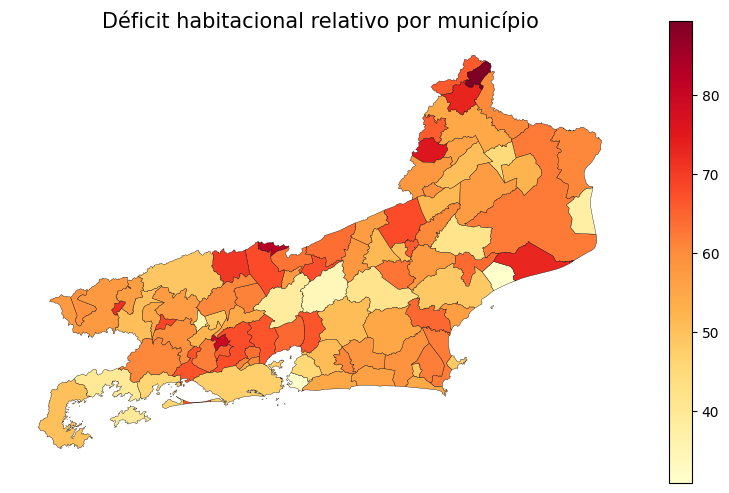

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

gdf_deficit.plot(
    column='deficit_relativo',
    ax=ax,
    legend=True,
    cmap='YlOrRd',
    edgecolor="black",
    linewidth=0.25
)

ax.set_title(
    "Déficit habitacional relativo por município",
    fontsize=15
)

ax.axis('off')
plt.show()

### Gráfico de barras empilhadas: tipos de inadequação por município

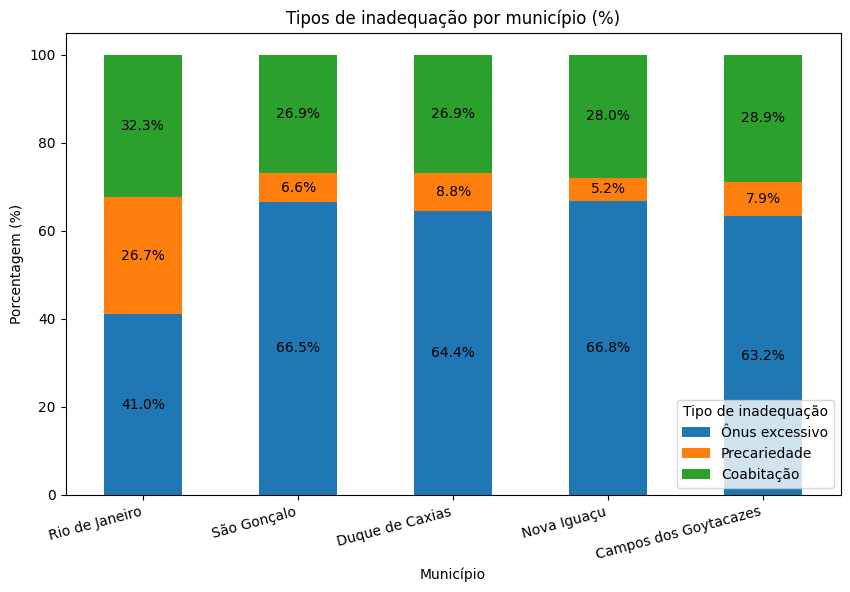

In [ ]:
fig, ax=plt.subplots(1, 1, figsize=(10, 6))

df_distribuicao.head(5).plot(x='NM_MUN',
                             y=['porcentagem_onus_excessivo','porcentagem_precariedade','porcentagem_coabitacao'],
                             ax=ax,
                             kind='bar',
                             stacked=True,)

for p in ax.containers:
  ax.bar_label(p, label_type='center', fmt='%.1f%%')

ax.set_title('Tipos de inadequação por município (%)')
plt.legend(['Ônus excessivo', 'Precariedade', 'Coabitação'], title='Tipo de inadequação', loc='lower right')
plt.xlabel('Município')
plt.ylabel('Porcentagem (%)')
plt.xticks(rotation=15, ha='right')
plt.show()

### Scatter: renda × déficit com bolhas proporcionais à população

In [ ]:
gdf_deficit = gdf_deficit.merge(
    df_renda,
    left_on='name',
    right_on='Município',
    how='left'
)

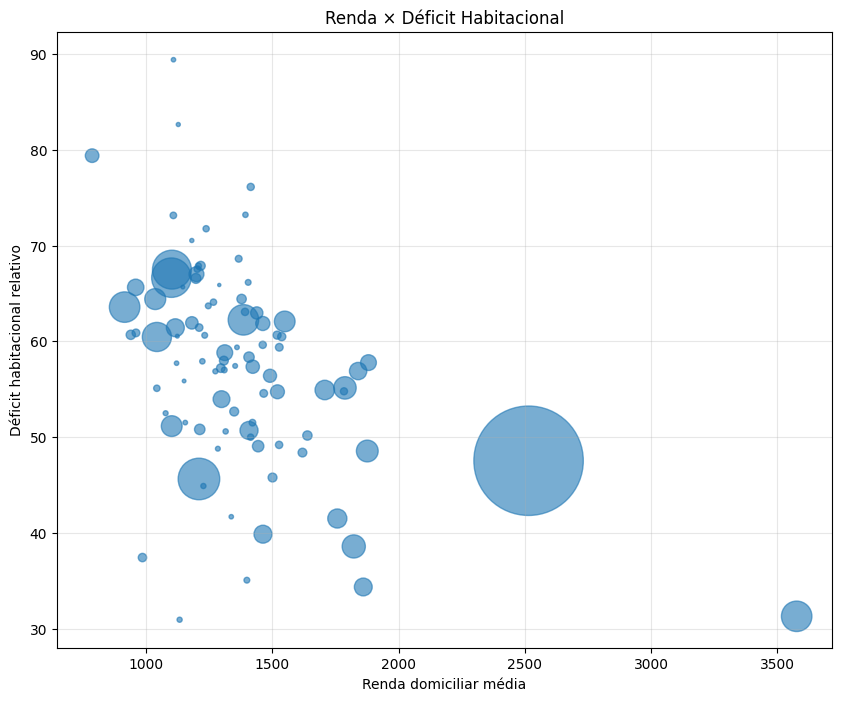

In [ ]:
plt.figure(figsize=(10, 8))

plt.scatter(
    gdf_deficit['renda'],
    gdf_deficit['deficit_relativo'],
    s=gdf_deficit['populacao'] / 1000,
    alpha=0.6
)

plt.xlabel('Renda domiciliar média')

plt.ylabel('Déficit habitacional relativo')

plt.title(
    'Renda × Déficit Habitacional'
)

plt.grid(alpha=0.3)

plt.show()

### Mapa de calor por setor censitário (foco na RMRJ)

In [ ]:
df_cols = df_setores[['CD_SETOR','v0001']]
df_cols = df_cols.rename(columns={'v0001': 'domicilios'})

gdfrj_setores['CD_SETOR'] = (
    gdfrj_setores['CD_SETOR']
    .astype(str)
    .str.strip()
)

df_cols['CD_SETOR'] = (
    df_cols['CD_SETOR']
    .astype(str)
    .str.strip()
)

gdf_heatmap = gdfrj_setores.merge(
    df_cols,
    on='CD_SETOR',
    how='left'
)

gdf_heatmap["domicilios"] = (pd.to_numeric(gdf_heatmap["domicilios"],errors="coerce").fillna(0))

In [ ]:
municipios_rmrj = [
    "Belford Roxo",
    "Cachoeiras de Macacu",
    "Duque de Caxias",
    "Guapimirim",
    "Itaboraí",
    "Itaguaí",
    "Japeri",
    "Magé",
    "Maricá",
    "Mesquita",
    "Nilópolis",
    "Niterói",
    "Nova Iguaçu",
    "Paracambi",
    "Queimados",
    "Rio Bonito",
    "Rio de Janeiro",
    "São Gonçalo",
    "São João de Meriti",
    "Seropédica",
    "Tanguá"
]

gdf_mun = gdf_muni_rj[gdf_muni_rj['name'].isin(municipios_rmrj)].copy()

gdf_heatmap = (gdf_heatmap[gdf_heatmap['NM_MUN'].isin(municipios_rmrj)])

gdf_mun = gdf_mun.to_crs(31983)
gdf_heatmap = gdf_heatmap.to_crs(31983)


In [ ]:
gdf_heatmap = gdf_heatmap[gdf_heatmap["AREA_KM2"] > 0].copy()

labels = {
    '0': "NE",
    '1': "FAV",
    '2': "QRT",
    '3': "ALO",
    '4': "BP",
    '5': "IND",
    '6': "PRI",
    '7': "INS",
    '8': "AGR",
    '9': "QUI"
}

gdf_heatmap["NM_TIPO"] = gdf_heatmap["CD_TIPO"].map(labels)
gdf_heatmap["densidade_log"] = np.log1p(gdf_heatmap["domicilios"] / gdf_heatmap["AREA_KM2"])

gdf_ne = gdf_heatmap[gdf_heatmap["CD_TIPO"] == '0']
gdf_tipo = gdf_heatmap[gdf_heatmap["CD_TIPO"] != '0']

from matplotlib.colors import LinearSegmentedColormap

hot_r_dk = LinearSegmentedColormap.from_list(
    "hot_r_dk",
    plt.cm.hot_r(np.linspace(0.05, 1, 256))
)

fig, ax = plt.subplots(figsize=(20, 20),  dpi=200)


gdf_mun.plot(
    ax=ax,
    color="#fffdcc",
    edgecolor="none",
    zorder=0
)

gdf_ne.plot(
    ax=ax,
    color="#fffdcc",
    edgecolor="black",
    linewidth=0.07,
    zorder=1
)


gdf_tipo.plot(
    column="densidade_log",
    ax=ax,
    cmap=hot_r_dk,
    legend=True,
    linewidth=0.04,
    edgecolor="black",
    zorder=2,
    legend_kwds={
        "shrink": 0.4,
        "aspect": 35,
        "pad": 0.01
    }
)

gdf_mun.boundary.plot(
    ax=ax,
    linewidth=0.4,
    color="black",
    zorder=100
)


for i, (_, row) in enumerate(gdf_heatmap.iterrows()):

    if row["CD_TIPO"] == '0':
        continue

    dens = row["densidade_log"]

    if 4 <= dens <= 7:
        mostrar = (i % 12 == 0)
    elif 1 <= dens <= 3:
        mostrar = True
    else:
        mostrar = (i % 50 == 0)

    if mostrar:

        x = row.geometry.centroid.x
        y = row.geometry.centroid.y

        ax.text(
            x,
            y,
            row["NM_TIPO"],
            fontsize=4
        )

ax.set_title("RMRJ – Mapa de Calor por Setor Censitário - Densidade Domiciliar", fontsize=15)
ax.set_axis_off()
ax.margins(0)


fig.patch.set_facecolor('#f5f5f5')
ax.set_facecolor('#f5f5f5')

plt.tight_layout(pad=0)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

### Treemap - Proporção dos tipos de inadequação no RJ

In [ ]:
df_treemap = pd.DataFrame({
    'tipo_inadequacao': ['Coabitação', 'Ônus excessivo', 'Precariedade'],
    'valor': [
        (df_inadequacao['coabitacao'] * df_inadequacao['domicilios']).sum(),
        (df_inadequacao['onus_excessivo'] * df_inadequacao['domicilios']).sum(),
        (df_inadequacao['precariedade'] * df_inadequacao['domicilios']).sum()
    ]
})

df_treemap['percentual'] = (df_treemap['valor'] / df_treemap['valor'].sum() * 100).round(1)

fig = px.treemap(
    df_treemap,
    path=['tipo_inadequacao'],
    values='valor',
    custom_data=['percentual']
)

fig.update_traces(
    texttemplate="%{label}<br>%{customdata[0]}%",
    textinfo="text",
    hovertemplate=None
)

fig.update_layout(
    title='Treemap - proporção dos tipos de inadequação no RJ',
    hovermode=False,
    width=700,
    height=450,
    margin=dict(t=40, l=20, r=20, b=20)
)

fig.show()